In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('household_power_consumption.txt', sep=';', 
                  parse_dates={'Datetime': ['Date', 'Time']}, 
                  infer_datetime_format=True,
                  na_values=['?'],
                  low_memory=False)

print("Dataset Shape:", df.shape)
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_524\1203100738.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt', sep=';',
C:\Users\HP\AppData\Local\Temp\ipykernel_524\1203100738.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('household_power_consumption.txt', sep=';',
C:\Users\HP\AppData\Local\Temp\ipykernel_524\1203100738.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('household_power_consumption.txt', sep=';',


Dataset Shape: (2075259, 8)


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df.set_index('Datetime', inplace=True)

df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df_hourly = df['Global_active_power'].resample('h').mean()
df_hourly = df_hourly.fillna(method='ffill')

print("Hourly Data Shape:", df_hourly.shape)
df_hourly.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_524\4208927647.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


Hourly Data Shape: (34589,)


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

In [4]:
df_features = df_hourly.reset_index()
df_features.columns = ['Datetime', 'Global_active_power']

df_features['Hour'] = df_features['Datetime'].dt.hour
df_features['DayOfWeek'] = df_features['Datetime'].dt.dayofweek
df_features['IsWeekend'] = df_features['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df_features['Month'] = df_features['Datetime'].dt.month

df_features.head()

,Datetime,Global_active_power,Hour,DayOfWeek,IsWeekend,Month
0,2006-12-16 17:00:00,4.222889,17,5,1,12
1,2006-12-16 18:00:00,3.632200,18,5,1,12
2,2006-12-16 19:00:00,3.400233,19,5,1,12
3,2006-12-16 20:00:00,3.268567,20,5,1,12
4,2006-12-16 21:00:00,3.056467,21,5,1,12


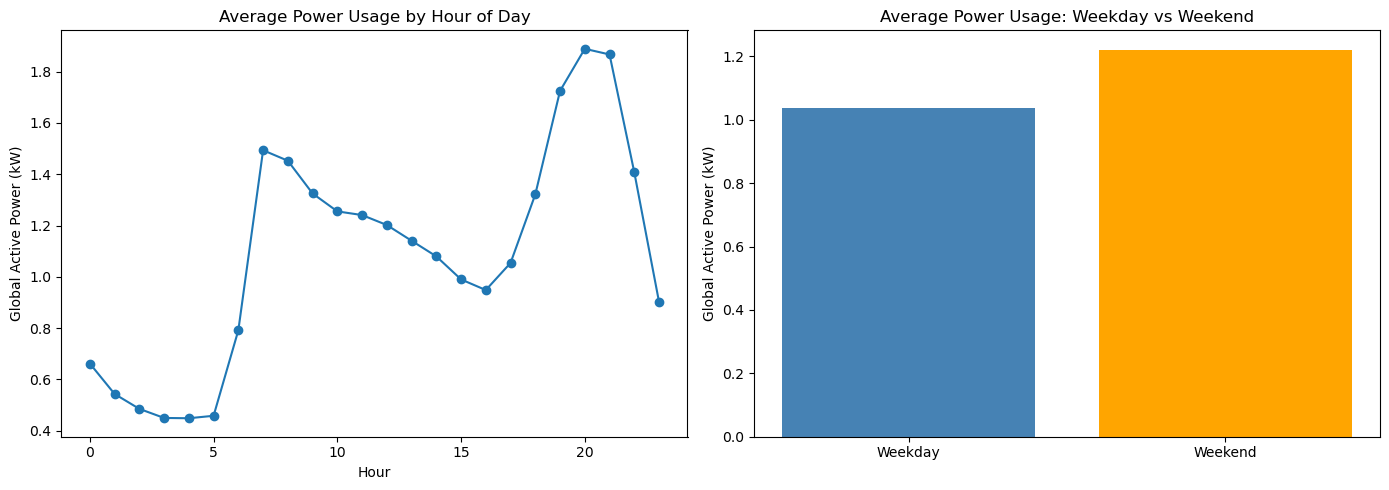

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

hourly_avg = df_features.groupby('Hour')['Global_active_power'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o')
axes[0].set_title('Average Power Usage by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Global Active Power (kW)')

weekend_avg = df_features.groupby('IsWeekend')['Global_active_power'].mean()
axes[1].bar(['Weekday', 'Weekend'], weekend_avg.values, color=['steelblue', 'orange'])
axes[1].set_title('Average Power Usage: Weekday vs Weekend')
axes[1].set_ylabel('Global Active Power (kW)')

plt.tight_layout()
plt.show()

In [6]:
train_size = int(len(df_features) * 0.9)
train = df_features.iloc[:train_size]
test = df_features.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))
print("Train period:", train['Datetime'].min(), "to", train['Datetime'].max())
print("Test period:", test['Datetime'].min(), "to", test['Datetime'].max())

Train size: 31130
Test size: 3459
Train period: 2006-12-16 17:00:00 to 2010-07-05 18:00:00
Test period: 2010-07-05 19:00:00 to 2010-11-26 21:00:00


In [7]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Global_active_power'], order=(2,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

print("ARIMA model trained successfully!")

c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA model trained successfully!


In [8]:
from prophet import Prophet

prophet_train = train[['Datetime', 'Global_active_power']].rename(columns={'Datetime': 'ds', 'Global_active_power': 'y'})

prophet_model = Prophet()
prophet_model.fit(prophet_train)

future = test[['Datetime']].rename(columns={'Datetime': 'ds'})
prophet_forecast = prophet_model.predict(future)

print("Prophet model trained successfully!")

17:43:32 - cmdstanpy - INFO - Chain [1] start processing
17:44:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [9]:
from xgboost import XGBRegressor

features = ['Hour', 'DayOfWeek', 'IsWeekend', 'Month']

X_train = train[features]
y_train = train['Global_active_power']
X_test = test[features]
y_test = test['Global_active_power']

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_mae = mean_absolute_error(test['Global_active_power'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['Global_active_power'], arima_forecast))

prophet_mae = mean_absolute_error(test['Global_active_power'], prophet_forecast['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(test['Global_active_power'], prophet_forecast['yhat']))

xgb_mae = mean_absolute_error(y_test, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_forecast))

results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [arima_mae, prophet_mae, xgb_mae],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse]
})

results

,Model,MAE,RMSE
0,ARIMA,0.555947,0.716779
1,Prophet,0.500479,0.646694
2,XGBoost,0.432619,0.613780


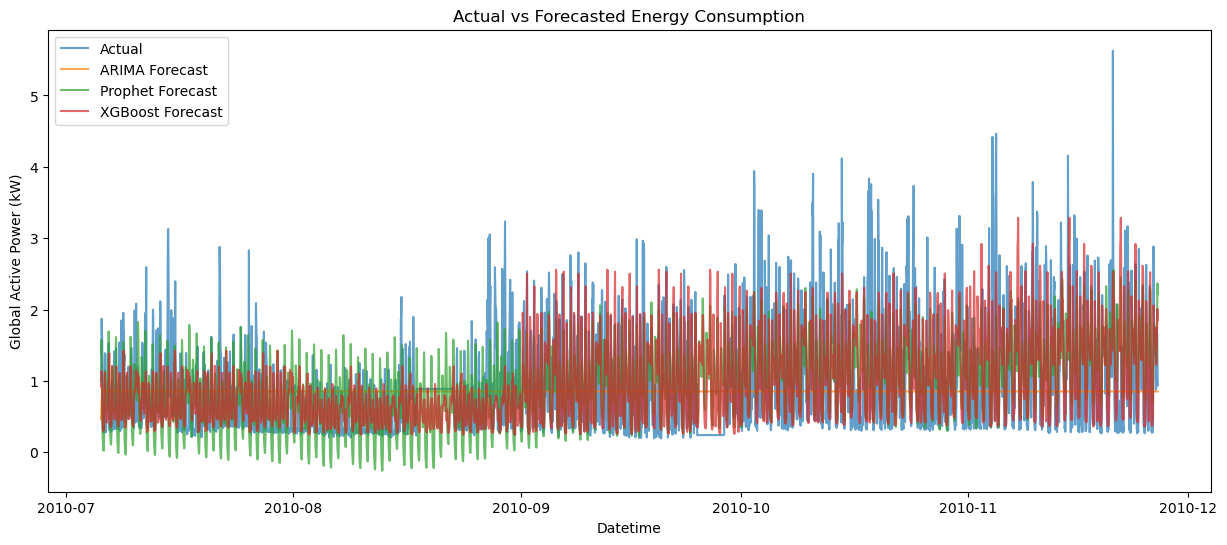

In [11]:
plt.figure(figsize=(15,6))
plt.plot(test['Datetime'].values, test['Global_active_power'].values, label='Actual', alpha=0.7)
plt.plot(test['Datetime'].values, arima_forecast.values, label='ARIMA Forecast', alpha=0.7)
plt.plot(test['Datetime'].values, prophet_forecast['yhat'].values, label='Prophet Forecast', alpha=0.7)
plt.plot(test['Datetime'].values, xgb_forecast, label='XGBoost Forecast', alpha=0.7)
plt.title('Actual vs Forecasted Energy Consumption')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

## Conclusion

- The household power consumption dataset was resampled from minute-level to hourly data for manageable forecasting.
- Time-based features (Hour, DayOfWeek, IsWeekend, Month) were engineered to capture daily and weekly usage patterns.
- Power usage peaks during evening hours (18:00-21:00) and is slightly higher on weekends.
- Three models were compared: ARIMA, Prophet, and XGBoost.
- XGBoost performed best with the lowest MAE (0.43) and RMSE (0.61), likely because it effectively leverages the engineered time-based features to capture recurring daily/weekly patterns, unlike ARIMA and Prophet which rely more on historical trend and seasonality.
- Future improvements could include adding weather data or holiday indicators to further improve forecast accuracy.